In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
class PolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
        self.coef_ = None

    def _poly_features(self, X):
        """
        Convert X into polynomial features
        X: shape (n_samples,) or (n_samples, 1)
        """
        X = np.array(X).reshape(-1, 1)

        features = [np.ones(len(X))]  # bias term (x^0)

        for d in range(1, self.degree + 1):
            features.append(X[:, 0] ** d)

        return np.column_stack(features)

    def fit(self, X, y):
        X_poly = self._poly_features(X)
        y = np.array(y)

        # Normal Equation: beta = (X^T X)^(-1) X^T y
        XT_X = X_poly.T @ X_poly
        XT_y = X_poly.T @ y

        self.coef_ = np.linalg.inv(XT_X) @ XT_y

    def predict(self, X):
        X_poly = self._poly_features(X)
        return X_poly @ self.coef_
    
    def plot_fit(self, X, y, resolution=100):
        """
        Plot original data + polynomial fit curve
        Only works for 1D input
        """

        X = np.array(X).reshape(-1, 1)
        y = np.array(y)

        if X.shape[1] != 1:
            raise ValueError("plot_fit only supports 1 feature (1D input)")

        # Sort X for smooth plotting
        X_sorted_idx = np.argsort(X[:, 0])
        X_sorted = X[X_sorted_idx]
        y_sorted = y[X_sorted_idx]

        # Create smooth X range
        X_range = np.linspace(X.min(), X.max(), resolution)
        y_pred = self.predict(X_range)

        # Plot
        plt.figure()
        plt.scatter(X, y)          # original data
        plt.plot(X_range, y_pred, 'red')  # fitted curve

        plt.xlabel("X")
        plt.ylabel("y")
        plt.title(f"Polynomial Regression (degree={self.degree})")

        plt.show()

In [70]:
# # Sample data
# X = np.array([1, 2, 3, 4, 5])
# y = np.array([1, 4, 9, 16, 25])  # quadratic pattern

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# print(X)
# print(y)

# y = 0.8x^2 + 0.9x + 2

# Train model
model = PolynomialRegression(degree=15)
model.fit(X, y)

# Predict
preds = model.predict([6, 7])
print(preds)

[[-2.60862496e+07]
 [-3.44612695e+08]]


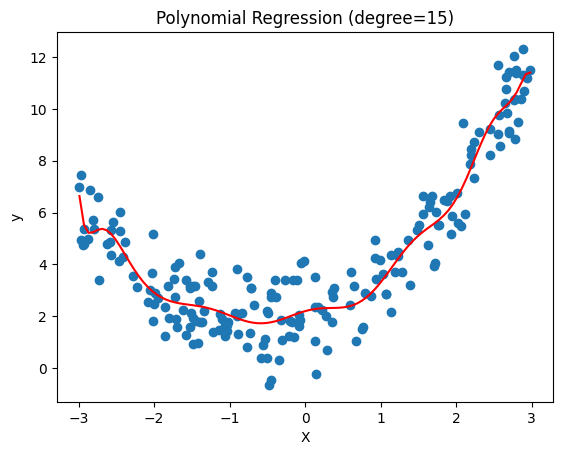

In [71]:
model.plot_fit(X, y)